# Preprocessing — MAGIC Gamma Telescope Dataset

---
**Goal:** Walk through the production preprocessing pipeline step by step:
1. Load raw data + encode labels (`g` → 1, `h` → 0)
2. Validate **physical constraints** on Hillas parameters
3. Engineer **7 physics-informed features** on top of the 10 raw ones
4. Stratified train/test split
5. **Borderline-SMOTE** on the train fold (with constraint-aware filtering of synthetic rows)
6. Standardize features

This notebook mirrors `src/preprocessing.py::run_pipeline` — you can call that one function and get the same outputs in one line.

## 1. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.feature_engineering import (
    RAW_FEATURES,
    ENGINEERED_FEATURES,
    ALL_FEATURES,
    engineer_features,
    validate_physical_constraints,
)
from src.preprocessing import (
    load_data,
    encode_labels,
    split_data,
    apply_borderline_smote,
    scale_features,
    run_pipeline,
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
print('Imports OK')
print(f'RAW_FEATURES         ({len(RAW_FEATURES)}):  {RAW_FEATURES}')
print(f'ENGINEERED_FEATURES  ({len(ENGINEERED_FEATURES)}):  {ENGINEERED_FEATURES}')
print(f'ALL_FEATURES         ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Imports OK
RAW_FEATURES         (10):  ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']
ENGINEERED_FEATURES  (7):  ['ellipticity', 'shower_density', 'miss_parameter', 'conc_ratio', 'm3_magnitude', 'size_conc', 'long_asymmetry']
ALL_FEATURES         (17): ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'ellipticity', 'shower_density', 'miss_parameter', 'conc_ratio', 'm3_magnitude', 'size_conc', 'long_asymmetry']


## 2. Load + Encode Labels

In [2]:
df = load_data(str(PROJECT_ROOT / 'data' / 'magic04.data'))
df = encode_labels(df)
df.head()

Data loaded: 19020 rows, 11 columns
Labels encoded: Gamma (1) = 12332, Hadron (0) = 6688


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


## 3. Physical Constraint Validation

The MAGIC raw Hillas parameters must satisfy:

| Constraint | Why |
|---|---|
| `fLength > 0`, `fWidth > 0` | ellipse axes must be positive |
| `fLength >= fWidth` | major axis cannot be smaller than the minor axis |
| `0 <= fConc, fConc1 <= 1` | concentrations are ratios |
| `fConc >= fConc1` | 2-pixel concentration contains the 1-pixel one |
| `0 <= fAlpha <= 90` | angle in degrees |
| `fDist > 0` | distance to centroid |

Any row violating these is non-physical and is dropped.

In [3]:
mask = validate_physical_constraints(df)
dropped = (~mask).sum()
print(f'Rows passing constraints: {mask.sum():>6} / {len(df)}')
print(f'Rows dropped:             {dropped:>6}')
df = df.loc[mask].reset_index(drop=True)

Rows passing constraints:  18922 / 19020
Rows dropped:                 98


## 4. Engineer 7 Physics-Informed Features

These are not arbitrary polynomial features — each has a physical interpretation:

| Feature | Formula | Physics rationale |
|---|---|---|
| `ellipticity` | `fLength / fWidth` | gamma showers are elongated, hadronic ones are more isotropic |
| `shower_density` | `fSize / (fLength * fWidth)` | light per unit area inside the ellipse |
| `miss_parameter` | `fDist * sin(fAlpha)` | perpendicular distance from the source direction |
| `conc_ratio` | `fConc / fConc1` | how peaked the brightest pixel is vs the top-2 |
| `m3_magnitude` | `√(fM3Long² + fM3Trans²)` | total third-moment magnitude |
| `size_conc` | `fSize * fConc` | energy-weighted concentration |
| `long_asymmetry` | `fAsym / fLength` | asymmetry normalized by length |

In [4]:
df_features = engineer_features(df.drop(columns=['class']))
df_features['class'] = df['class'].values
print(f'Shape after engineering: {df_features.shape}  ({len(RAW_FEATURES)} raw + {len(ENGINEERED_FEATURES)} engineered)')
df_features[ENGINEERED_FEATURES].describe().round(3)

Shape after engineering: (18922, 18)  (10 raw + 7 engineered)


,ellipticity,shower_density,miss_parameter,conc_ratio,m3_magnitude,size_conc,long_asymmetry
count,18922.000,18922.000,18922.000,18922.000,18922.000,18922.000,18922.000
mean,63.249,0.221,72.575,1.821,41.422,0.998,0.060
std,3321.508,11.643,70.702,0.952,38.020,0.364,0.795
min,1.002,0.000,0.000,1.015,0.914,0.058,-4.296
25%,1.646,0.002,18.422,1.700,17.479,0.726,-0.552
50%,2.223,0.004,46.795,1.833,26.555,0.968,0.126
75%,3.018,0.008,109.061,1.928,53.563,1.247,0.694
max,264513.355,913.857,490.495,109.000,337.254,2.274,3.153


### 4.1 How well do engineered features separate the classes?

Density plots per class for each new feature — ideally we want non-overlapping distributions.

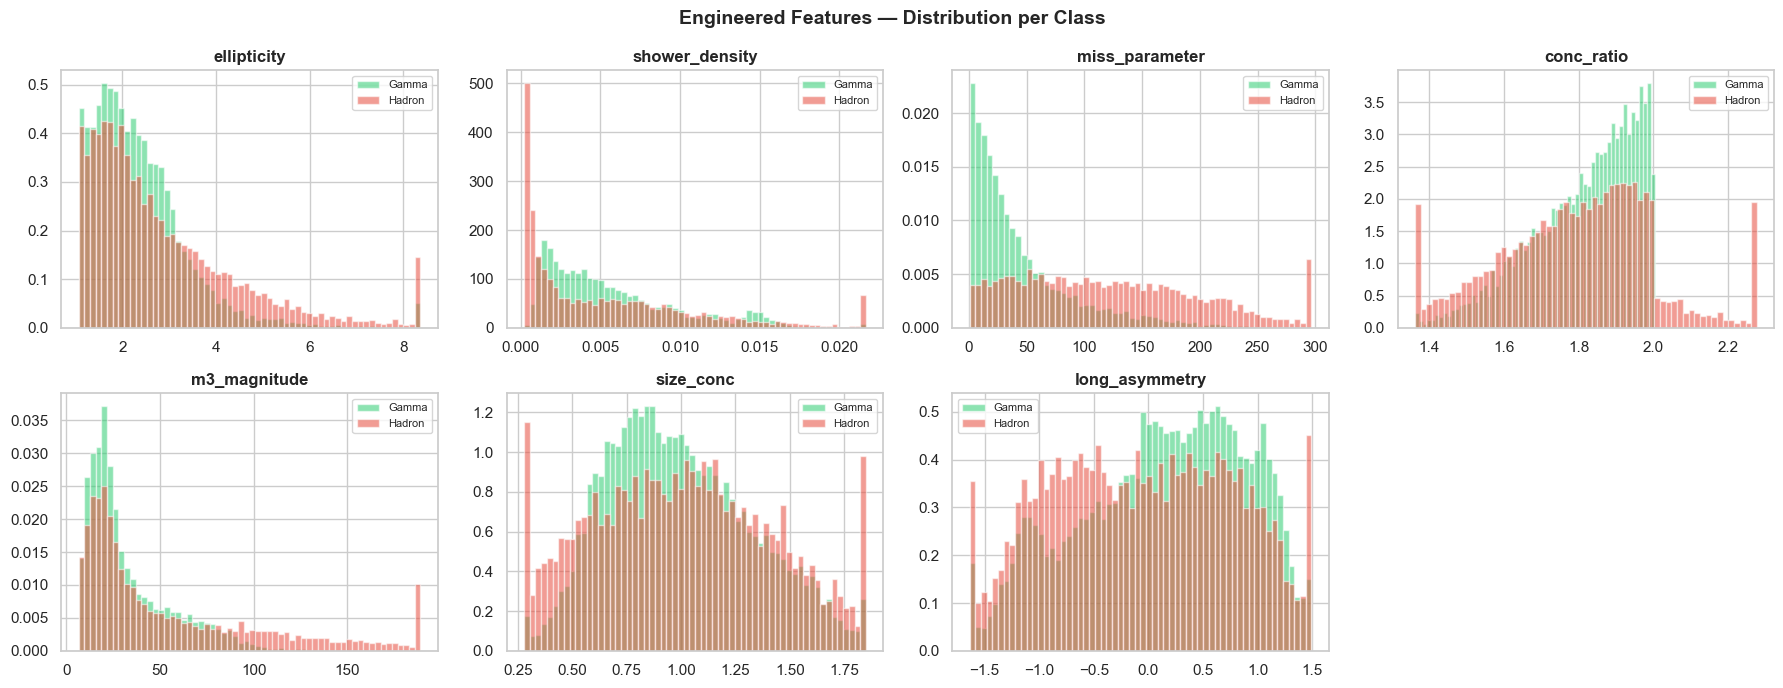

In [5]:
gamma  = df_features[df_features['class'] == 1]
hadron = df_features[df_features['class'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(ENGINEERED_FEATURES):
    # robust x-limits to drop extreme tails for readable plots
    lo, hi = np.quantile(df_features[feat], [0.01, 0.99])
    axes[i].hist(gamma[feat].clip(lo, hi),  bins=60, alpha=0.55, color='#2ecc71', density=True, label='Gamma')
    axes[i].hist(hadron[feat].clip(lo, hi), bins=60, alpha=0.55, color='#e74c3c', density=True, label='Hadron')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')  # 7 features, 8 axes
plt.suptitle('Engineered Features — Distribution per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Stratified Train/Test Split

80 / 20 split with `stratify=y` so the gamma:hadron ratio is preserved.

In [6]:
X_train, X_test, y_train, y_test = split_data(df_features)
print(f'\nGamma ratio in TRAIN: {y_train.mean():.4f}')
print(f'Gamma ratio in TEST:  {y_test.mean():.4f}')
print(f'Difference: {abs(y_train.mean() - y_test.mean()):.4f}  (should be tiny)')

Train: (15137, 17), Test: (3785, 17)

Gamma ratio in TRAIN: 0.6476
Gamma ratio in TEST:  0.6476
Difference: 0.0001  (should be tiny)


## 6. Borderline-SMOTE on the Train Fold

The dataset is imbalanced (≈65% gamma). Borderline-SMOTE generates synthetic minority-class points along the decision boundary instead of in the safe interior.

Crucially, **we then check synthetic rows against `validate_physical_constraints`** and drop any that violate — SMOTE in feature space can create rows that are physically impossible.

If more than 30 % of synthetic rows are dropped, the function emits a warning (would suggest falling back to SMOTE on raw features and re-engineering).

SMOTE: 15137 -> 19606 (synthetic=4469, dropped=0 = 0.0%)


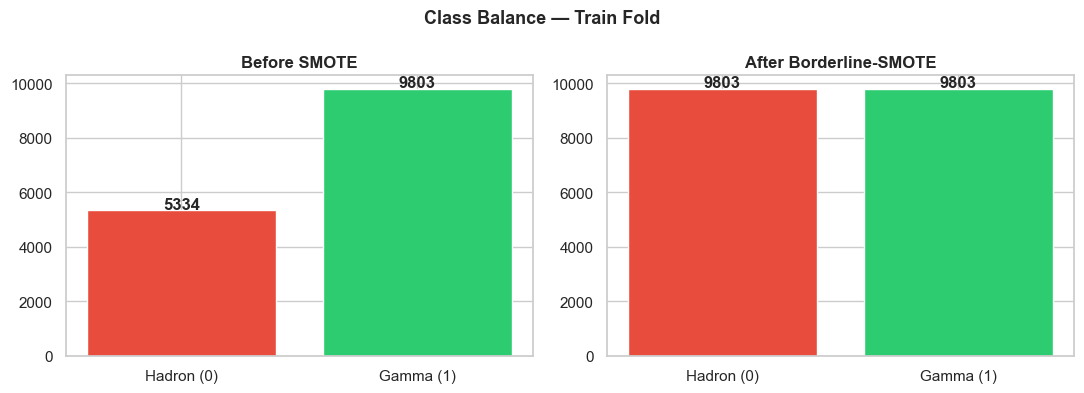

In [7]:
before = y_train.value_counts().to_dict()
X_train_smote, y_train_smote = apply_borderline_smote(X_train, y_train)
after = y_train_smote.value_counts().to_dict()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (counts, title) in zip(axes, [(before, 'Before SMOTE'), (after, 'After Borderline-SMOTE')]):
    ax.bar(['Hadron (0)', 'Gamma (1)'], [counts[0], counts[1]],
           color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Balance — Train Fold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. StandardScaler

Fit on **train only** (post-SMOTE), apply to both train and test — this prevents test-set leakage into the scaling statistics.

In [8]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train_smote, X_test)

stats = pd.DataFrame({
    'Mean (train)': X_train_scaled.mean().round(4),
    'Std (train)':  X_train_scaled.std().round(4),
    'Mean (test)':  X_test_scaled.mean().round(4),
    'Std (test)':   X_test_scaled.std().round(4),
})
stats

Scaled 17 features (mean=0, std=1)


,Mean (train),Std (train),Mean (test),Std (test)
fLength,-0.0,1.0,0.1178,1.0861
fWidth,-0.0,1.0,0.1090,1.0973
fSize,-0.0,1.0,0.1117,1.0929
fConc,-0.0,1.0,-0.1368,1.0052
fConc1,0.0,1.0,-0.1419,0.9838
fAsym,0.0,1.0,-0.0608,1.1018
fM3Long,-0.0,1.0,-0.0004,1.0825
fM3Trans,0.0,1.0,-0.0022,1.1059
fAlpha,0.0,1.0,-0.0592,1.0196
fDist,-0.0,1.0,0.0845,1.0235


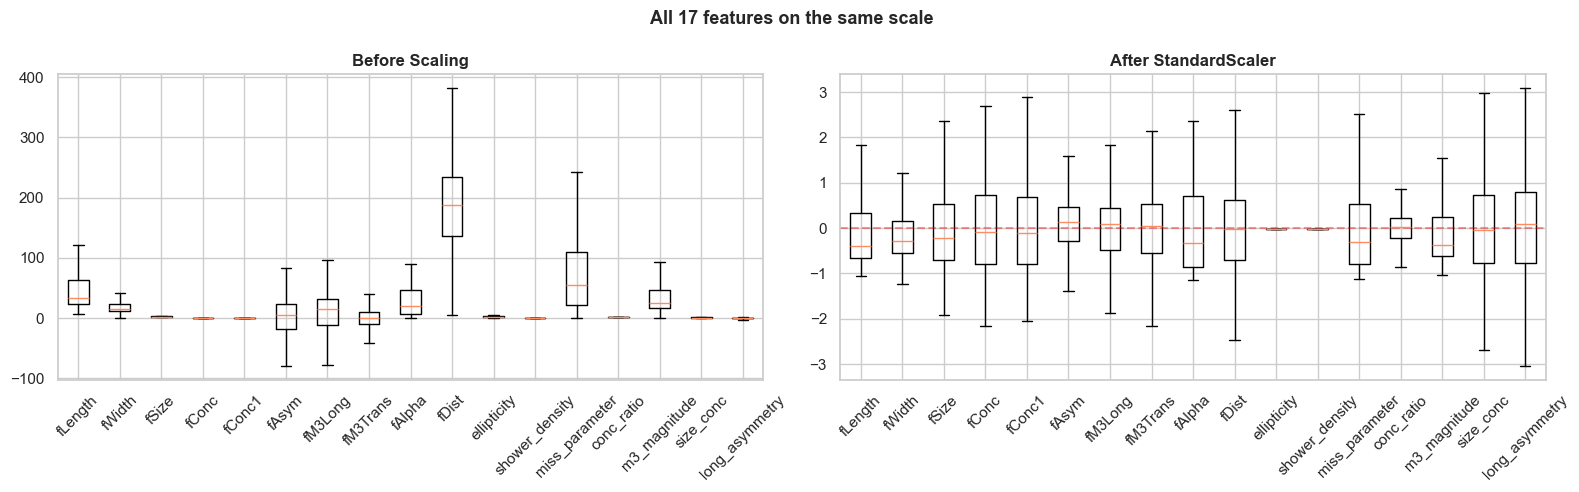

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].boxplot([X_train_smote[f].values for f in ALL_FEATURES], labels=ALL_FEATURES, showfliers=False)
axes[0].set_title('Before Scaling', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].boxplot([X_train_scaled[f].values for f in ALL_FEATURES], labels=ALL_FEATURES, showfliers=False)
axes[1].set_title('After StandardScaler', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.4)

plt.suptitle('All 17 features on the same scale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. One-line Equivalent: `run_pipeline`

Everything we just did step by step is wrapped in a single call. This is what `src/train_stacking.py` uses.

In [10]:
Xtr, Xte, ytr, yte, _ = run_pipeline(
    filepath=str(PROJECT_ROOT / 'data' / 'magic04.data'),
    apply_smote=True,
)
print(f'\nReturned: X_train {Xtr.shape}, X_test {Xte.shape}, y_train {ytr.shape}, y_test {yte.shape}')

  MAGIC Telescope — Preprocessing Pipeline (engineered + SMOTE)
Data loaded: 19020 rows, 11 columns
Labels encoded: Gamma (1) = 12332, Hadron (0) = 6688
Dropped 98 raw rows violating physical constraints
Train: (15137, 17), Test: (3785, 17)
SMOTE: 15137 -> 19606 (synthetic=4469, dropped=0 = 0.0%)
Scaled 17 features (mean=0, std=1)

Pipeline complete.

Returned: X_train (19606, 17), X_test (3785, 17), y_train (19606,), y_test (3785,)


## 9. Summary

| Step | Why |
|------|-----|
| Physical-constraint validation | drops non-physical rows that would confuse the model |
| 7 engineered features | encode domain knowledge (ellipticity, miss parameter, etc.) |
| Stratified split | preserves class ratio in train/test |
| Borderline-SMOTE on train | handles imbalance; synthetic rows are constraint-checked |
| StandardScaler fit on train only | no leakage; all 17 features on comparable scale |

**Next:** `03_Modeling.ipynb` — feature selection, Optuna tuning, stacking ensemble, SHAP.